# Data Exploration & Data Preprocessing Method 研究

> Goal: 理解資料集、使牙齒輪廓更清晰

使用 `data/original` 的影像測試前處理。請由上往下執行；支援從專案根目錄或 `notebooks` 目錄啟動。
影像保留原始尺寸與像素範圍，不會寫入或修改原始檔案。需要專案環境中的 OpenCV、NumPy 與 Matplotlib。


In [1]:
from pathlib import Path
import re

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 向上尋找資料目錄，避免依賴 notebook 的啟動位置。
working_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (directory for directory in [working_dir, *working_dir.parents]
     if (directory / "data" / "original").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("找不到 data/original，請從專案根目錄或 notebooks 目錄啟動。")

DATA_DIR = PROJECT_ROOT / "data" / "original"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# 自然排序：1.jpg、2.jpg、10.jpg。
def natural_key(path):
    return [int(part) if part.isdigit() else part.lower()
            for part in re.split(r"(\d+)", path.name)]

image_paths = sorted(
    (path for path in DATA_DIR.iterdir()
     if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS),
    key=natural_key,
)
if not image_paths:
    raise FileNotFoundError(f"資料夾內沒有支援的影像：{DATA_DIR}")

print(f"資料目錄：{DATA_DIR}")
print(f"影像數量：{len(image_paths)}")
print("前 10 個檔名：", [path.name for path in image_paths[:10]])


資料目錄：/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original
影像數量：282
前 10 個檔名： ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg', '10.jpg']


## 載入函式與資料檢查

`load_image(path)` 回傳 RGB 的 `uint8` NumPy 陣列，形狀為 `(height, width, 3)`；
`load_image(path, grayscale=True)` 回傳灰階陣列，形狀為 `(height, width)`。
每次只載入需要的影像，避免將全部原始影像同時放入記憶體。


In [2]:
def load_image(path, grayscale=False):
    """載入影像，保留原始尺寸；讀取失敗時提供檔案路徑。"""
    path = Path(path)
    # imdecode 支援含中文的路徑。
    encoded = np.frombuffer(path.read_bytes(), dtype=np.uint8)
    if encoded.size == 0:
        raise ValueError(f"影像檔案是空的：{path}")
    image = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"無法解碼影像：{path}")
    if grayscale:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# 逐張檢查能否讀取，僅保留檔案資訊，不保留全部像素。
image_info = []
failed_images = []
for path in image_paths:
    try:
        image = load_image(path)
        height, width = image.shape[:2]
        image_info.append({
            "filename": path.name,
            "path": path,
            "height": height,
            "width": width,
            "channels": image.shape[2],
            "dtype": str(image.dtype),
        })
        del image
    except (OSError, ValueError, cv2.error) as error:
        failed_images.append({"path": path, "error": str(error)})

valid_image_paths = [info["path"] for info in image_info]
print(f"成功載入：{len(valid_image_paths)} / {len(image_paths)}")
print("影像尺寸 (height, width)：", sorted({(info["height"], info["width"]) for info in image_info}))
if failed_images:
    print("讀取失敗：")
    for failure in failed_images:
        print(f"  {failure['path'].name}: {failure['error']}")
if not valid_image_paths:
    raise ValueError("沒有可讀取的影像，請檢查上述錯誤。")

image_info[:5]


成功載入：282 / 282
影像尺寸 (height, width)： [(549, 790), (552, 793), (553, 785), (553, 789), (554, 788), (555, 787), (555, 789), (558, 788), (570, 790), (571, 790), (620, 476), (787, 567), (787, 570), (787, 572), (789, 574), (792, 575), (797, 550), (804, 623), (806, 563), (812, 572), (825, 1200), (856, 1200), (1190, 1699), (1194, 1719), (1200, 825), (1200, 1696), (1201, 1696), (1227, 1704), (1228, 1707), (1232, 1706), (1232, 1712), (1234, 1705), (1324, 1842), (1700, 1196), (1702, 1198), (1703, 1200), (1704, 1192), (1704, 1214), (1707, 1225), (1708, 1194), (1708, 1197), (1709, 1237), (1712, 1212), (1715, 1199), (1715, 1241), (1720, 2400), (1724, 1208), (1733, 1212), (1744, 1246), (1747, 1384), (1842, 1324), (2400, 1720)]


[{'filename': '1.jpg',
  'path': PosixPath('/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original/1.jpg'),
  'height': 1200,
  'width': 825,
  'channels': 3,
  'dtype': 'uint8'},
 {'filename': '2.jpg',
  'path': PosixPath('/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original/2.jpg'),
  'height': 1200,
  'width': 825,
  'channels': 3,
  'dtype': 'uint8'},
 {'filename': '3.jpg',
  'path': PosixPath('/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original/3.jpg'),
  'height': 825,
  'width': 1200,
  'channels': 3,
  'dtype': 'uint8'},
 {'filename': '4.jpg',
  'path': PosixPath('/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original/4.jpg'),
  'height': 1200,
  'width': 825,
  'channels': 3,
  'dtype': 'uint8'},
 {'filename': '5.jpg',
  'path': PosixPath('/home/cliffyang/Program/Medical-CV/IOT-Program/CRR_Ratio/data/original/5.jpg'),
  'height': 825,
  'width': 1200,
  'channels': 3,
  'dtype': 'uint8'}]

## 原始影像預覽

預覽前 6 張可讀取的影像。後續可使用 `image_paths`、`valid_image_paths` 和 `load_image()` 選取資料。


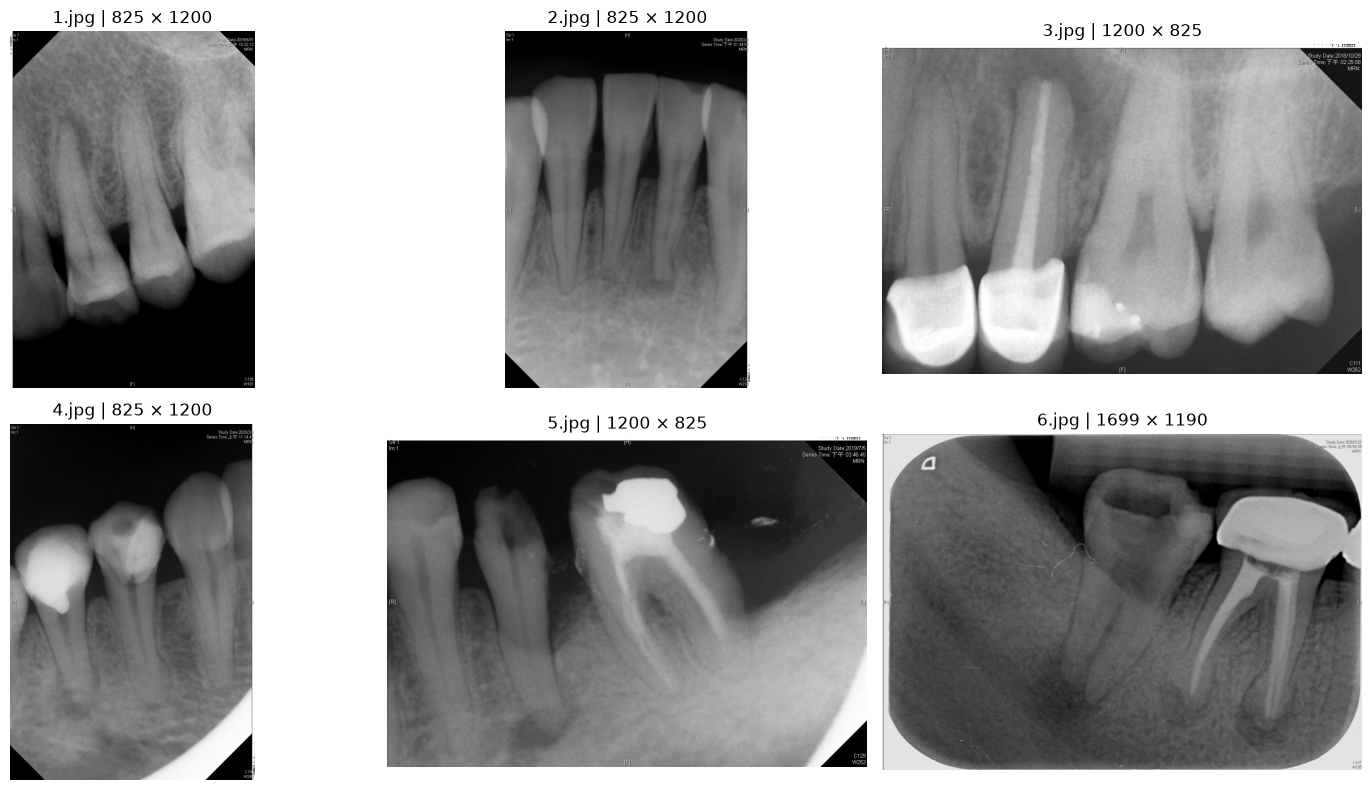

In [3]:
preview_paths = valid_image_paths[:6]
columns = 3
rows = (len(preview_paths) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows), squeeze=False)
for axis in axes.flat:
    axis.axis("off")
for axis, path in zip(axes.flat, preview_paths):
    image = load_image(path)
    axis.imshow(image)
    axis.set_title(f"{path.name} | {image.shape[1]} × {image.shape[0]}")
plt.tight_layout()
plt.show()


In [4]:
# 修改索引即可選擇後續前處理實驗的影像。
selected_path = valid_image_paths[0]
original_image = load_image(selected_path)
gray_image = load_image(selected_path, grayscale=True)

print(f"選取影像：{selected_path.name}")
print(f"RGB：shape={original_image.shape}, dtype={original_image.dtype}")
print(f"灰階：shape={gray_image.shape}, dtype={gray_image.dtype}")


選取影像：1.jpg
RGB：shape=(1200, 825, 3), dtype=uint8
灰階：shape=(1200, 825), dtype=uint8


## 研究影像處理

### 1. 去除雜訊

- 傅立葉轉換, 低通濾波, 反傅立葉轉換
- 中值濾波器
- Bilateral Filter
- Non-Local Means
- Anisotropic Diffusion
- Wavelet Denoising
- BM3D

#### 方法與參數

以下兩種方法分別作用於同一張原始灰階影像，方便比較：

- **傅立葉低通濾波**：FFT → 將零頻移到中心 → 乘上高斯低通遮罩 → 移回頻率位置 → IFFT。`cutoff_frequency` 是高斯遮罩的頻率標準差（cycles/pixel）；數值越小，平滑越強。高斯遮罩可減少理想硬截止遮罩造成的振鈴。先對影像做反射填補，降低 FFT 週期邊界的影響，最後裁回原尺寸。
- **中值濾波**：以鄰域像素的中位數取代中心像素，適合測試脈衝／椒鹽雜訊的去除。`median_kernel_size` 設為 3 或 5；越大通常平滑越強。

平滑也可能減少牙齒邊界等細節；此處提供視覺比較，沒有乾淨參考影像時，不將平滑程度當作去雜訊品質的證明。


In [5]:
def fourier_low_pass(image, cutoff_frequency=0.08):
    """對 2D uint8 灰階影像做高斯低通，回傳影像與頻域診斷資料。"""
    if image.ndim != 2 or image.dtype != np.uint8:
        raise ValueError("請傳入 2D uint8 灰階影像。")
    if not np.isfinite(cutoff_frequency) or not 0 < cutoff_frequency <= 0.5:
        raise ValueError("cutoff_frequency 必須介於 0（不含）到 0.5。")

    # 約四倍空間標準差的反射填補；padding 不改變輸出尺寸。
    padding = max(1, int(np.ceil(4 / (2 * np.pi * cutoff_frequency))))
    padded = np.pad(image.astype(np.float64), padding, mode="reflect")
    spectrum = np.fft.fftshift(np.fft.fft2(padded))
    fy = np.fft.fftshift(np.fft.fftfreq(padded.shape[0]))[:, None]
    fx = np.fft.fftshift(np.fft.fftfreq(padded.shape[1]))[None, :]
    low_pass_mask = np.exp(-(fx**2 + fy**2) / (2 * cutoff_frequency**2))
    filtered_spectrum = spectrum * low_pass_mask
    reconstructed = np.fft.ifft2(np.fft.ifftshift(filtered_spectrum)).real
    height, width = image.shape
    cropped = reconstructed[padding:padding + height, padding:padding + width]
    # 不重新正規化亮度，保留與原圖一致的像素尺度。
    result = np.clip(np.rint(cropped), 0, 255).astype(np.uint8)
    return result, spectrum, low_pass_mask, filtered_spectrum


def median_denoise(image, kernel_size=3):
    """以 3×3 或 5×5 鄰域做中值濾波。"""
    if image.ndim != 2 or image.dtype != np.uint8:
        raise ValueError("請傳入 2D uint8 灰階影像。")
    if isinstance(kernel_size, bool) or kernel_size not in (3, 5):
        raise ValueError("kernel_size 請設為 3 或 5。")
    return cv2.medianBlur(image, int(kernel_size))


In [6]:
# 可修改影像索引與參數，再重新執行本 cell 及下方比較圖。
image_index = 0
cutoff_frequency = 0.08
median_kernel_size = 3

selected_path = valid_image_paths[image_index]
original_image = load_image(selected_path)
gray_image = load_image(selected_path, grayscale=True)
fft_denoised, fft_spectrum, fft_mask, fft_filtered_spectrum = fourier_low_pass(
    gray_image, cutoff_frequency=cutoff_frequency
)
median_denoised = median_denoise(gray_image, kernel_size=median_kernel_size)

print(f"影像：{selected_path.name} | 灰階尺寸：{gray_image.shape}")
print(f"高斯低通頻率標準差：{cutoff_frequency} cycles/pixel")
print(f"中值濾波鄰域：{median_kernel_size} × {median_kernel_size}")


影像：1.jpg | 灰階尺寸：(1200, 825)
高斯低通頻率標準差：0.08 cycles/pixel
中值濾波鄰域：3 × 3


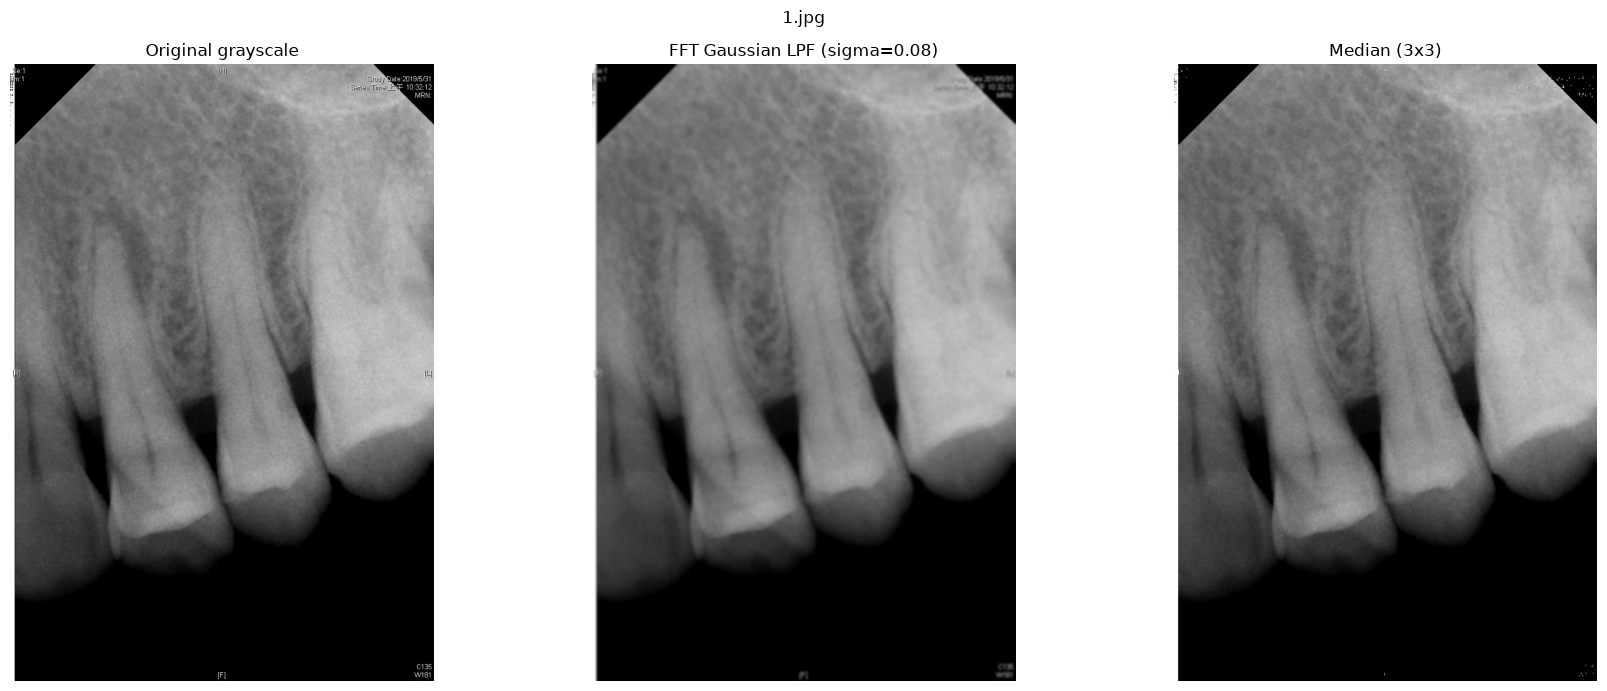

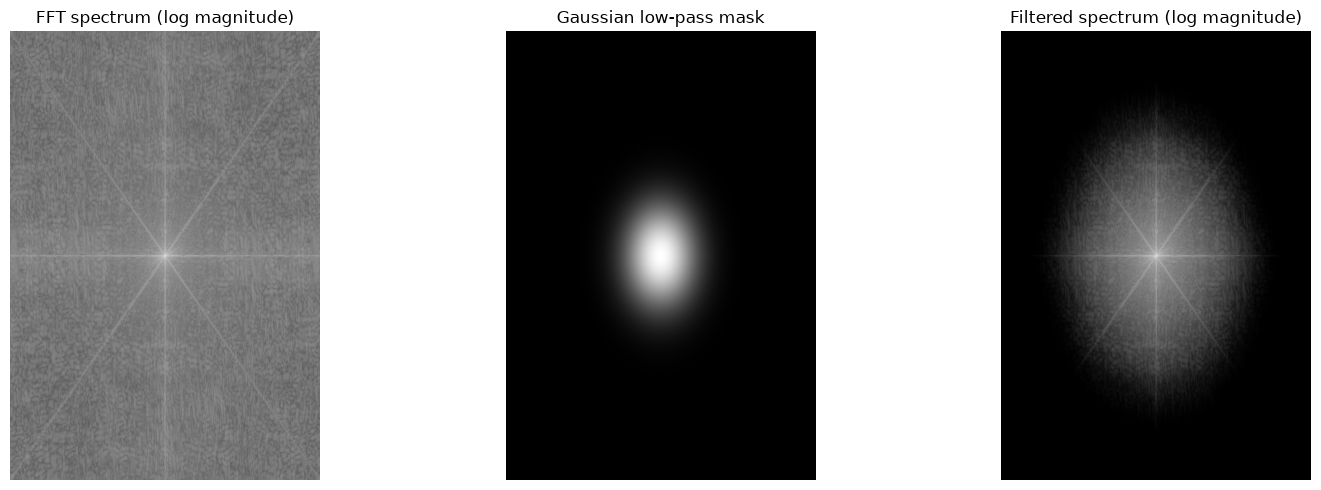

In [7]:
# 三張影像使用相同顯示範圍，避免自動縮放亮度影響比較。
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for axis, image, title in zip(
    axes,
    [gray_image, fft_denoised, median_denoised],
    ["Original grayscale", f"FFT Gaussian LPF (sigma={cutoff_frequency})",
     f"Median ({median_kernel_size}x{median_kernel_size})"],
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
fig.suptitle(selected_path.name)
plt.tight_layout()
plt.show()

# log(1 + |FFT|) 顯示頻譜；濾波前後共用色階。
log_spectrum = np.log1p(np.abs(fft_spectrum))
log_filtered_spectrum = np.log1p(np.abs(fft_filtered_spectrum))
spectrum_max = log_spectrum.max()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(log_spectrum, cmap="gray", vmin=0, vmax=spectrum_max)
axes[0].set_title("FFT spectrum (log magnitude)")
axes[1].imshow(fft_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Gaussian low-pass mask")
axes[2].imshow(log_filtered_spectrum, cmap="gray", vmin=0, vmax=spectrum_max)
axes[2].set_title("Filtered spectrum (log magnitude)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


#### 保留邊緣的去雜訊方法

所有方法使用灰階 `uint8`；輸出保留尺寸與 0–255 尺度。參數集中在下方函式，先以保守強度比較。
Bilateral 兼顧空間距離與亮度差；NLM 比較相似區塊；Anisotropic Diffusion 使用 Perona–Malik 四鄰域擴散（每步 0.2，無週期邊界）；Wavelet 使用 BayesShrink 軟閾值；BM3D 使用真正的 `bm3d` 套件，不以其他濾波器代替。

BM3D 是選用依賴：`python -m pip install -r notebooks/requirements-preprocessing.txt`（從專案根目錄執行）。未安裝時明確略過該方法；其授權請參考 [套件頁面](https://pypi.org/project/bm3d/)。
Wavelet API 參考 [scikit-image](https://scikit-image.org/docs/stable/api/skimage.restoration.html)，Bilateral／NLM 參考 [OpenCV](https://docs.opencv.org/4.x/d5/d69/tutorial_py_non_local_means.html)。

Wavelet／BM3D 的自動雜訊估計可能被黑邊、量化與既有壓縮影響而低估；可用 `wavelet_denoise(image, sigma_gray=...)` 或 `bm3d_denoise(image, sigma_gray=...)` 指定以 0–255 灰階尺度表示的雜訊標準差。本次評估使用自動估計，結論限於這組設定。


Original    : 0.000 s
FFT         : 0.044 s
Median      : 0.000 s
Bilateral   : 0.002 s
NLM         : 0.090 s
Diffusion   : 0.076 s
Wavelet     : 0.025 s


BM3D        : 5.191 s


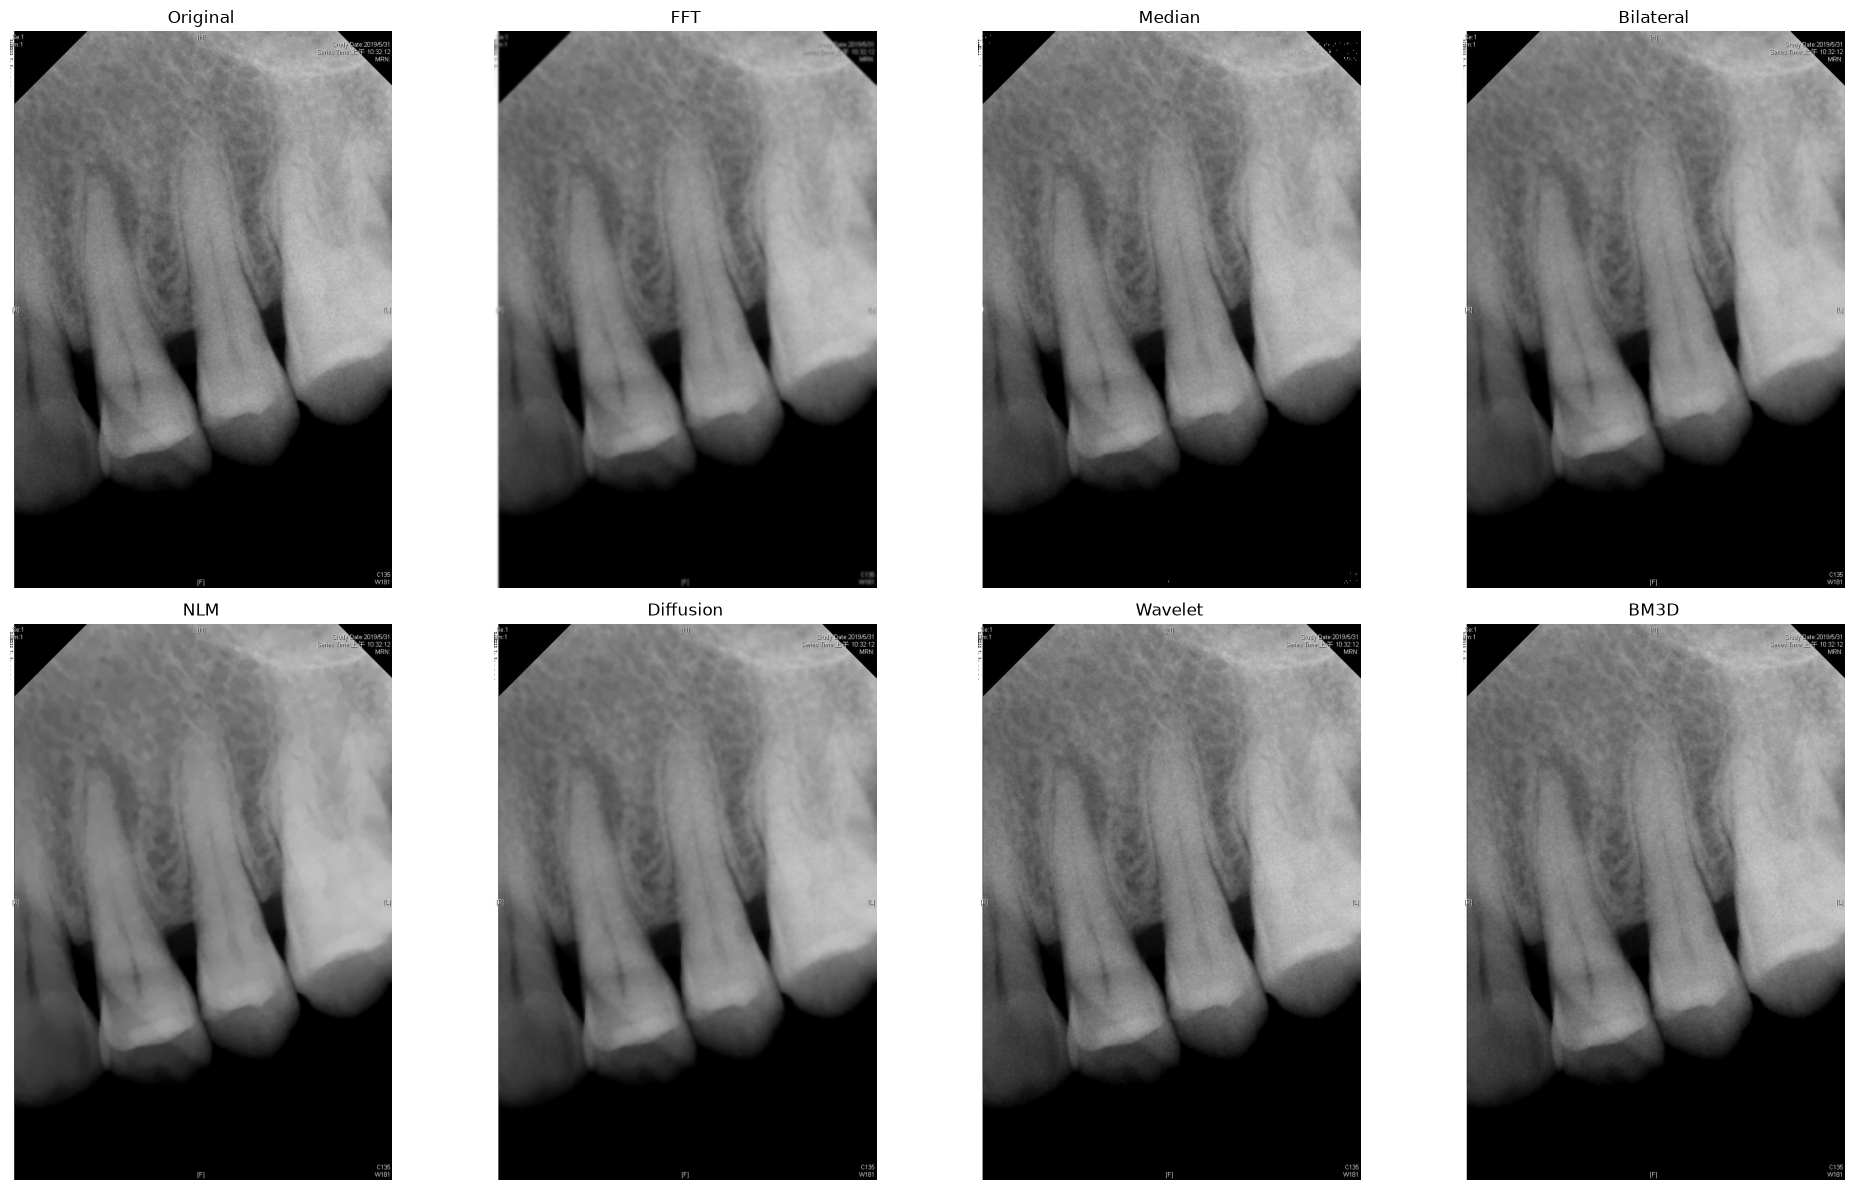

In [8]:
from time import perf_counter
from collections import defaultdict
import csv
import json
from skimage.restoration import denoise_wavelet, estimate_sigma

try:
    import bm3d as bm3d_package
except ImportError:
    bm3d_package = None
    print("BM3D 尚未安裝：此次比較略過，請安裝 bm3d 後重跑。")


def to_uint8(image):
    return np.clip(np.rint(image), 0, 255).astype(np.uint8)


def anisotropic_diffusion(image, iterations=12, kappa=15.0, step=0.2):
    if image.ndim != 2 or image.dtype != np.uint8:
        raise ValueError("需要 2D uint8 影像。")
    if not isinstance(iterations, int) or iterations < 1 or kappa <= 0 or not 0 < step <= 0.25:
        raise ValueError("iterations >= 1、kappa > 0，且 0 < step <= 0.25。")
    result = image.astype(np.float32)
    for _ in range(iterations):
        padded = np.pad(result, 1, mode="edge")
        differences = [padded[:-2, 1:-1] - result, padded[2:, 1:-1] - result,
                       padded[1:-1, :-2] - result, padded[1:-1, 2:] - result]
        result += step * sum(delta * np.exp(-(delta / kappa)**2) for delta in differences)
    return to_uint8(result)


def wavelet_denoise(image, sigma_gray=None):
    if sigma_gray is not None and (not np.isfinite(sigma_gray) or sigma_gray <= 0):
        raise ValueError("sigma_gray 必須為有限正數。")
    result = denoise_wavelet(image / 255.0, sigma=None if sigma_gray is None else sigma_gray / 255, method="BayesShrink", mode="soft",
                             wavelet="db2", rescale_sigma=True, channel_axis=None)
    return to_uint8(result * 255)


def bm3d_denoise(image, sigma_gray=None):
    if bm3d_package is None:
        raise ImportError("請安裝 bm3d；不使用替代演算法。")
    normalized = image.astype(np.float64) / 255
    sigma = max(float(estimate_sigma(normalized, channel_axis=None)), 1 / 255) if sigma_gray is None else sigma_gray / 255
    if sigma <= 0 or not np.isfinite(sigma):
        raise ValueError("sigma_gray 必須為有限正數。")
    return to_uint8(bm3d_package.bm3d(normalized, sigma_psd=sigma) * 255)


DENOISERS = {
    "Original": lambda image: image.copy(),
    "FFT": lambda image: fourier_low_pass(image, 0.08)[0],
    "Median": lambda image: median_denoise(image, 3),
    "Bilateral": lambda image: cv2.bilateralFilter(image, 7, 20, 3),
    "NLM": lambda image: cv2.fastNlMeansDenoising(image, None, 5, 7, 21),
    "Diffusion": anisotropic_diffusion,
    "Wavelet": wavelet_denoise,
}
if bm3d_package is not None:
    DENOISERS["BM3D"] = bm3d_denoise

# 同圖比較，保留所有新增方法的可重用輸出。
denoised_images = {}
denoise_times = {}
for name, method in DENOISERS.items():
    start = perf_counter()
    denoised_images[name] = method(gray_image)
    denoise_times[name] = perf_counter() - start
    print(f"{name:12s}: {denoise_times[name]:.3f} s")

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for axis in axes.flat:
    axis.axis("off")
for axis, (name, image) in zip(axes.flat, denoised_images.items()):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(name)
plt.tight_layout()
plt.show()


### 2. 增強對比與邊緣


比較不增強、CLAHE，以及 CLAHE 後的輕度 unsharp mask。CLAHE `clipLimit=2`、`tileGridSize=(8,8)`；銳化半徑 1 pixel、強度 0.5，只放大絕對值超過 3 灰階的細節，以降低微小雜訊放大。這些是起始參數，不代表對所有影像都最佳。


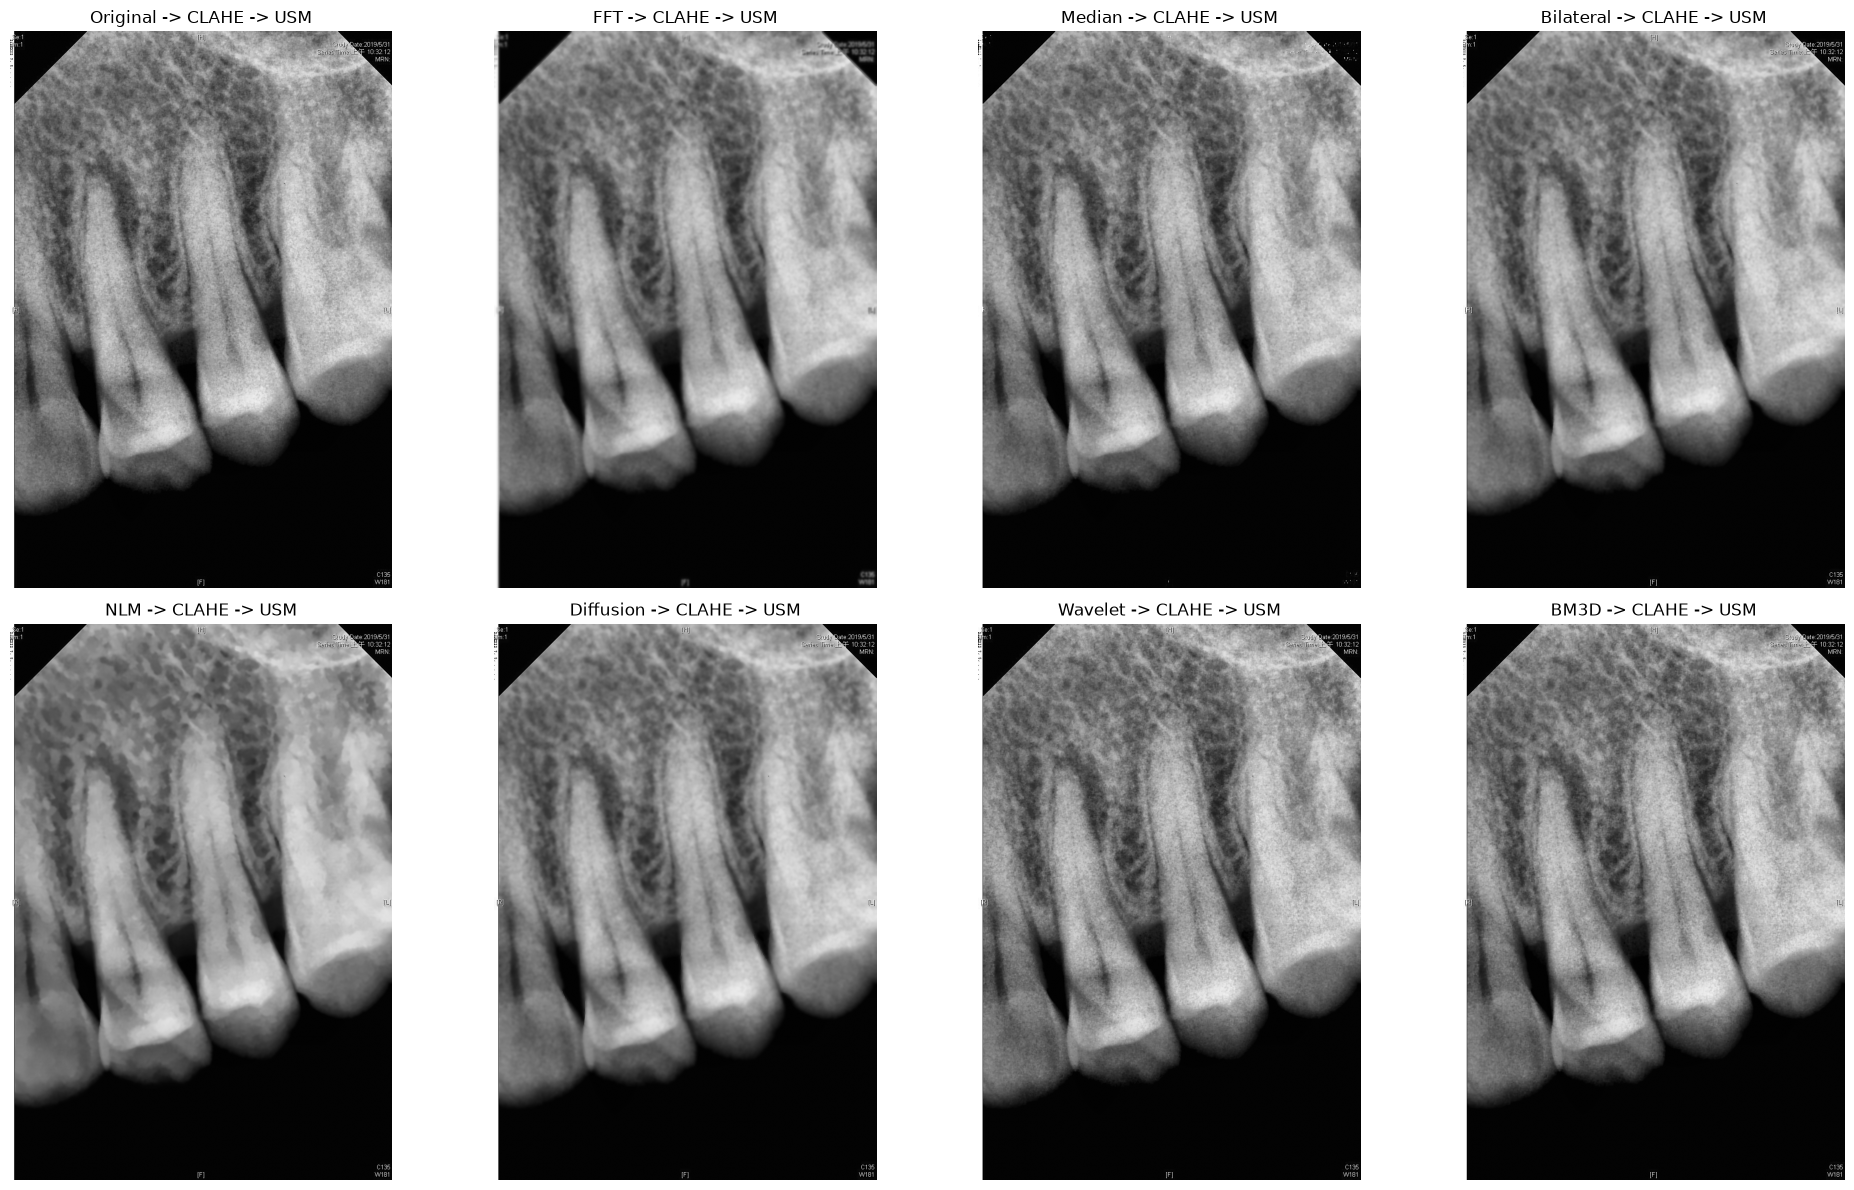

In [9]:
def enhance_image(image, mode="CLAHE", clip_limit=2.0, amount=0.5):
    if mode == "None":
        return image.copy()
    if mode not in ("CLAHE", "CLAHE+USM"):
        raise ValueError("mode 必須為 None、CLAHE 或 CLAHE+USM。")
    enhanced = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8)).apply(image)
    if mode == "CLAHE+USM":
        base = enhanced.astype(np.float32)
        detail = base - cv2.GaussianBlur(base, (0, 0), 1.0)
        enhanced = to_uint8(base + amount * np.where(np.abs(detail) >= 3, detail, 0))
    return enhanced


enhanced_images = {name: enhance_image(image, "CLAHE+USM")
                   for name, image in denoised_images.items()}
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for axis in axes.flat:
    axis.axis("off")
for axis, (name, image) in zip(axes.flat, enhanced_images.items()):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"{name} -> CLAHE -> USM")
plt.tight_layout()
plt.show()


### 3. 以牙齒標註評估單一與組合方法

使用 `data/seg_annotations/instances_default.json` 中 `tooth` 多邊形；以檔名 stem 配對 `.png` 標註與 `.jpg` 原圖，並檢查原圖尺寸是否一致。分別繪製每顆牙齒的輪廓，保留相鄰牙齒間的界線。

預設使用全部有匹配牙齒標註的影像；設 `evaluation_count=12` 可均勻取樣加速。評估影像等比例縮到最長邊 768（不放大），標註使用相同比例；此評估是初步篩選，原尺寸的效果須另外確認。設 `evaluation_count=None` 可跑全部有匹配標註的影像，`evaluation_max_side=None` 可評估原尺寸。

- `boundary_recall`：Canny 邊緣在標註輪廓 3 pixel 內的覆蓋率；標註可能不完全沿著真實灰階邊緣，不能當作分割準確率。
- `boundary_gradient`：固定輪廓帶內平均 Sobel 梯度，觀察邊緣訊號。
- `flat_residual`：在**原圖固定低梯度區域**內（限牙齒與鄰近區域，排除黑邊及接近飽和的像素），高通殘差的穩健標準差；它是紋理／雜訊代理值，不是真實雜訊量。
- `edge_to_flat`：輪廓梯度 / (`flat_residual` + 1)，供平滑與邊緣強度的折衷比較；過度平滑也可能讓此值升高，不單獨以它判定優勝。
- `flat_edge_density`：固定低梯度區內 Canny 邊緣比例，觀察新增的細碎邊緣。
- `saturation`：像素落在 0 或 255 的比例，觀察亮度截斷；`seconds` 包含去雜訊與增強。

固定 Canny 閾值 40/100、相同評估区域；每張圖先計算指標，再跨影像取中位數，並報告四分位數。原始灰階只作為輪廓與平坦區域定位依據；它含原本雜訊，不拿來計算去雜訊 PSNR／SSIM。

另比較 NLM、Bilateral、Diffusion 的低強度版本，以檢查原參數是否過度平滑。


In [10]:
def gradient_magnitude(image):
    image = image.astype(np.float32)
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3, scale=1 / 8)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3, scale=1 / 8)
    return cv2.magnitude(gx, gy)


def annotation_cases(annotation_path):
    annotations = json.loads(Path(annotation_path).read_text())
    tooth_ids = {item["id"] for item in annotations["categories"] if item["name"].lower() == "tooth"}
    grouped = defaultdict(list)
    for item in annotations["annotations"]:
        if item["category_id"] in tooth_ids:
            if not isinstance(item["segmentation"], list):
                raise ValueError("目前支援多邊形標註，遇到 RLE 請先轉換。")
            grouped[item["image_id"]].extend(item["segmentation"])
    by_stem = {path.stem: path for path in valid_image_paths}
    cases = []
    for item in annotations["images"]:
        path = by_stem.get(Path(item["file_name"]).stem)
        polygons = grouped[item["id"]]
        if path is not None and polygons:
            cases.append((path, item, polygons))
    return sorted(cases, key=lambda case: natural_key(case[0]))


def prepare_case(case, max_side=768):
    path, metadata, polygons = case
    image = load_image(path, grayscale=True)
    if image.shape != (metadata["height"], metadata["width"]):
        raise ValueError(f"標註尺寸與原圖不符：{path.name}")
    height, width = image.shape
    scale = min(1.0, max_side / max(height, width)) if max_side else 1.0
    new_width, new_height = max(1, round(width * scale)), max(1, round(height * scale))
    image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
    boundary = np.zeros(image.shape, np.uint8)
    tooth_region = np.zeros(image.shape, np.uint8)
    for polygon in polygons:
        points = np.asarray(polygon, dtype=np.float64).reshape(-1, 2)
        points *= [new_width / width, new_height / height]
        contour = np.rint(points).astype(np.int32)
        cv2.polylines(boundary, [contour], True, 255, 1)
        cv2.fillPoly(tooth_region, [contour], 1)
    boundary[:4] = boundary[-4:] = 0
    boundary[:, :4] = boundary[:, -4:] = 0
    boundary = boundary > 0
    if not boundary.any():
        raise ValueError(f"無有效輪廓：{path.name}")
    band = cv2.dilate(boundary.astype(np.uint8), np.ones((7, 7), np.uint8)) > 0
    original_gradient = gradient_magnitude(cv2.GaussianBlur(image, (0, 0), 1))
    tissue = (cv2.dilate(tooth_region, np.ones((25, 25), np.uint8)) > 0) & (image > 5) & (image < 250)
    if tissue.sum() < 100:
        raise ValueError(f"有效牙齒附近區域不足：{path.name}")
    flat = tissue & (original_gradient <= np.percentile(original_gradient[tissue], 25))
    flat &= ~cv2.dilate(boundary.astype(np.uint8), np.ones((15, 15), np.uint8)).astype(bool)
    flat[:4] = flat[-4:] = False
    flat[:, :4] = flat[:, -4:] = False
    if flat.sum() < 100:
        raise ValueError(f"平坦區域不足：{path.name}")
    return image, boundary, band, flat


def evaluate_output(output, boundary, band, flat):
    edges = cv2.Canny(output, 40, 100, L2gradient=True)
    near_edge = cv2.dilate((edges > 0).astype(np.uint8), np.ones((7, 7), np.uint8)) > 0
    residual = output.astype(np.float32) - cv2.GaussianBlur(output.astype(np.float32), (0, 0), 1)
    values = residual[flat]
    flat_residual = float(1.4826 * np.median(np.abs(values - np.median(values))))
    boundary_gradient = float(gradient_magnitude(output)[band].mean())
    return {
        "boundary_recall": float(near_edge[boundary].mean()),
        "boundary_gradient": boundary_gradient,
        "flat_residual": flat_residual,
        "edge_to_flat": boundary_gradient / (flat_residual + 1),
        "flat_edge_density": float((edges[flat] > 0).mean()),
        "saturation": float(((output == 0) | (output == 255)).mean()),
    }


EVALUATION_DENOISERS = {**DENOISERS,
    "NLM-light": lambda image: cv2.fastNlMeansDenoising(image, None, 2, 7, 21),
    "Bilateral-light": lambda image: cv2.bilateralFilter(image, 5, 10, 2),
    "Diffusion-light": lambda image: anisotropic_diffusion(image, iterations=4, kappa=8),
}


def benchmark_methods(evaluation_count=None, evaluation_max_side=768):
    cases = annotation_cases(PROJECT_ROOT / "data/seg_annotations/instances_default.json")
    if not cases:
        raise ValueError("沒有匹配的牙齒多邊形標註。")
    if evaluation_count is not None:
        if not isinstance(evaluation_count, int) or evaluation_count < 1:
            raise ValueError("evaluation_count 必須是正整數或 None。")
        indices = np.unique(np.linspace(0, len(cases) - 1, min(evaluation_count, len(cases))).round().astype(int))
        cases = [cases[index] for index in indices]
    records = []
    for index, case in enumerate(cases):
        image, boundary, band, flat = prepare_case(case, evaluation_max_side)
        for name, method in EVALUATION_DENOISERS.items():
            start = perf_counter()
            denoised = method(image)
            denoise_seconds = perf_counter() - start
            for mode in ["None", "CLAHE", "CLAHE+USM"]:
                start = perf_counter()
                output = enhance_image(denoised, mode)
                seconds = denoise_seconds + perf_counter() - start
                records.append({"filename": case[0].name, "method": name, "enhancement": mode,
                                "height": image.shape[0], "width": image.shape[1],
                                **evaluate_output(output, boundary, band, flat), "seconds": seconds})
        print(f"評估 {index + 1}/{len(cases)}：{case[0].name}", flush=True)
    groups = defaultdict(list)
    for record in records:
        groups[(record["method"], record["enhancement"])].append(record)
    metrics = ["boundary_recall", "boundary_gradient", "flat_residual", "edge_to_flat", "flat_edge_density", "saturation", "seconds"]
    summary = []
    for (method, enhancement), rows in groups.items():
        row = {"method": method, "enhancement": enhancement, "images": len(rows)}
        for metric in metrics:
            values = [item[metric] for item in rows]
            row[metric] = float(np.median(values))
            row[metric + "_q25"] = float(np.percentile(values, 25))
            row[metric + "_q75"] = float(np.percentile(values, 75))
        summary.append(row)
    return records, summary


evaluation_count = None
evaluation_max_side = 768
benchmark_records, benchmark_summary = benchmark_methods(evaluation_count, evaluation_max_side)
report_dir = PROJECT_ROOT / "reports" / "preprocessing"
report_dir.mkdir(parents=True, exist_ok=True)
for filename, rows in [("per_image.csv", benchmark_records), ("summary.csv", benchmark_summary)]:
    with (report_dir / filename).open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
config = {"evaluation_count": evaluation_count, "max_side": evaluation_max_side,
          "files": list(dict.fromkeys(row["filename"] for row in benchmark_records)),
          "methods": list(EVALUATION_DENOISERS), "canny_thresholds": [40, 100], "boundary_tolerance": 3,
          "parameters": {"FFT_cutoff": 0.08, "Median_kernel": 3, "Bilateral": [7,20,3],
                         "NLM": [5,7,21], "NLM-light": [2,7,21], "Bilateral-light": [5,10,2], "Diffusion-light": [4,8,0.2], "Diffusion": [12,15,0.2], "Wavelet": "db2/BayesShrink/soft",
                         "BM3D_sigma": "estimate_sigma; min 1/255", "CLAHE": [2.0,8,8], "USM": [1.0,0.5,3]},
          "versions": {"numpy": np.__version__, "opencv": cv2.__version__,
                       "skimage": __import__("skimage").__version__,
                       "bm3d": __import__("importlib.metadata", fromlist=["version"]).version("bm3d") if bm3d_package else None}}
(report_dir / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False))
print("\n方法 / 增強                    輪廓覆蓋  輪廓梯度  平坦殘差  邊緣/殘差  平坦邊緣  截斷比例  秒")
for row in benchmark_summary:
    print(f"{row['method']:10s} {row['enhancement']:10s} "
          f"{row['boundary_recall']:8.3f} {row['boundary_gradient']:9.2f} "
          f"{row['flat_residual']:9.2f} {row['edge_to_flat']:9.2f} "
          f"{row['flat_edge_density']:9.3f} {row['saturation']:9.3f} {row['seconds']:7.3f}")
print(f"\n完整逐圖結果與四分位數：{report_dir}")


評估 1/101：1.jpg
評估 2/101：10.jpg


評估 3/101：11.jpg
評估 4/101：12.jpg
評估 5/101：13.jpg
評估 6/101：14.jpg
評估 7/101：15.jpg
評估 8/101：16.jpg
評估 9/101：17.jpg
評估 10/101：18.jpg
評估 11/101：19.jpg
評估 12/101：100.jpg
評估 13/101：101.jpg
評估 14/101：102.jpg
評估 15/101：103.jpg
評估 16/101：104.jpg
評估 17/101：105.jpg
評估 18/101：107.jpg
評估 19/101：108.jpg
評估 20/101：109.jpg
評估 21/101：110.jpg
評估 22/101：111.jpg
評估 23/101：112.jpg
評估 24/101：113.jpg
評估 25/101：114.jpg
評估 26/101：115.jpg
評估 27/101：116.jpg
評估 28/101：117.jpg
評估 29/101：118.jpg
評估 30/101：119.jpg
評估 31/101：120.jpg
評估 32/101：121.jpg
評估 33/101：122.jpg
評估 34/101：123.jpg
評估 35/101：124.jpg
評估 36/101：125.jpg
評估 37/101：126.jpg
評估 38/101：127.jpg
評估 39/101：128.jpg
評估 40/101：129.jpg
評估 41/101：130.jpg
評估 42/101：131.jpg
評估 43/101：132.jpg
評估 44/101：133.jpg
評估 45/101：134.jpg
評估 46/101：135.jpg
評估 47/101：136.jpg
評估 48/101：137.jpg
評估 49/101：138.jpg
評估 50/101：139.jpg
評估 51/101：140.jpg
評估 52/101：141.jpg
評估 53/101：142.jpg
評估 54/101：143.jpg
評估 55/101：144.jpg
評估 56/101：145.jpg
評估 57/101：146.jpg
評估 58/101：147.jpg
評估 59/10

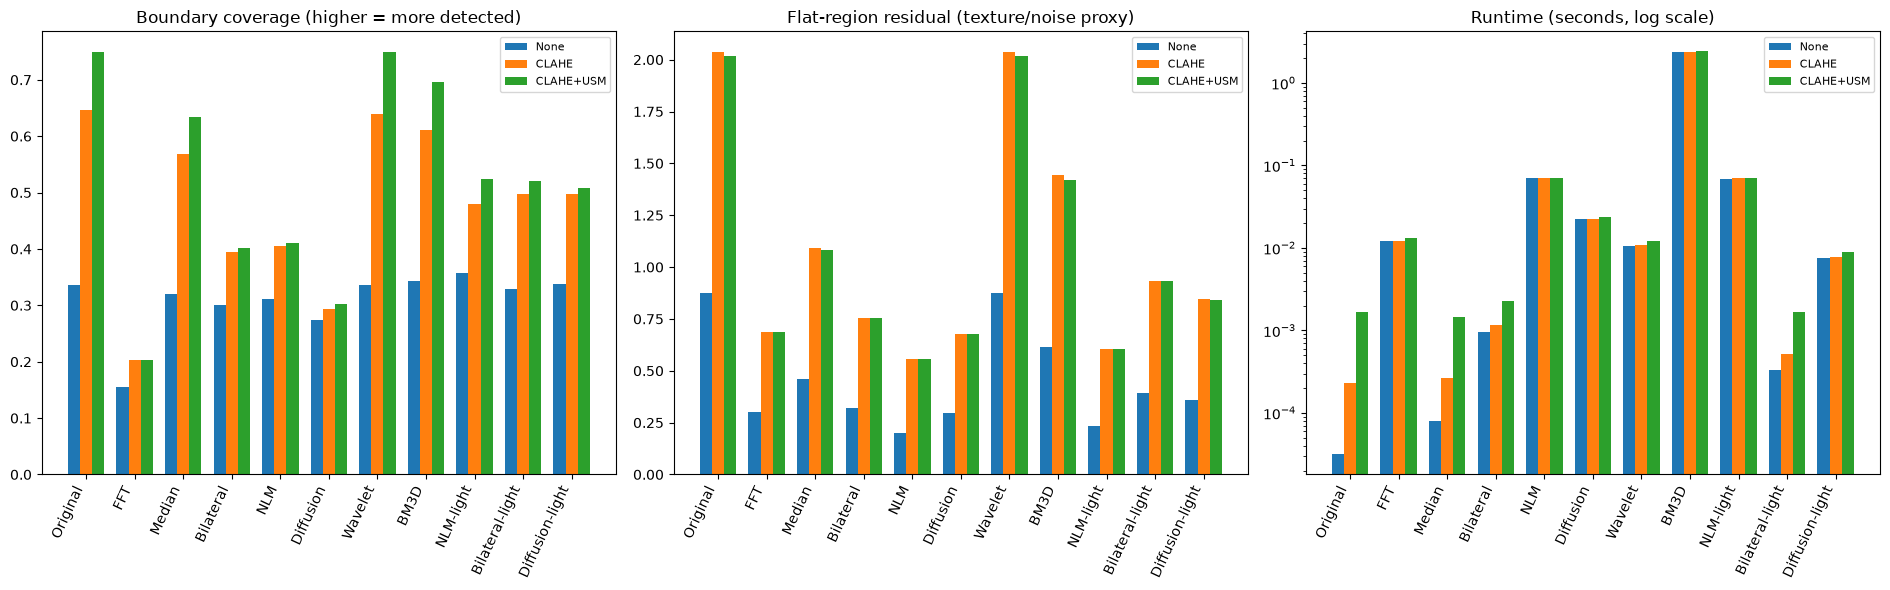

In [11]:
# 對照輪廓覆蓋、平坦殘差與執行時間；不將三者合成單一排名。
method_names = list(EVALUATION_DENOISERS)
lookup = {(row["method"], row["enhancement"]): row for row in benchmark_summary}
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for axis, metric, label in zip(axes,
    ["boundary_recall", "flat_residual", "seconds"],
    ["Boundary coverage (higher = more detected)", "Flat-region residual (texture/noise proxy)", "Runtime (seconds, log scale)"]):
    for index, mode in enumerate(["None", "CLAHE", "CLAHE+USM"]):
        values = [lookup[(name, mode)][metric] for name in method_names]
        axis.bar(np.arange(len(method_names)) + (index - 1) * 0.25,
                 np.maximum(values, 1e-5) if metric == "seconds" else values,
                 width=0.25, label=mode)
    axis.set_xticks(np.arange(len(method_names)), method_names, rotation=65, ha="right")
    axis.set_title(label)
    if metric == "seconds":
        axis.set_yscale("log")
    axis.legend(fontsize=8)
plt.tight_layout()
plt.savefig(report_dir / "metrics_comparison.png", dpi=150)
plt.show()


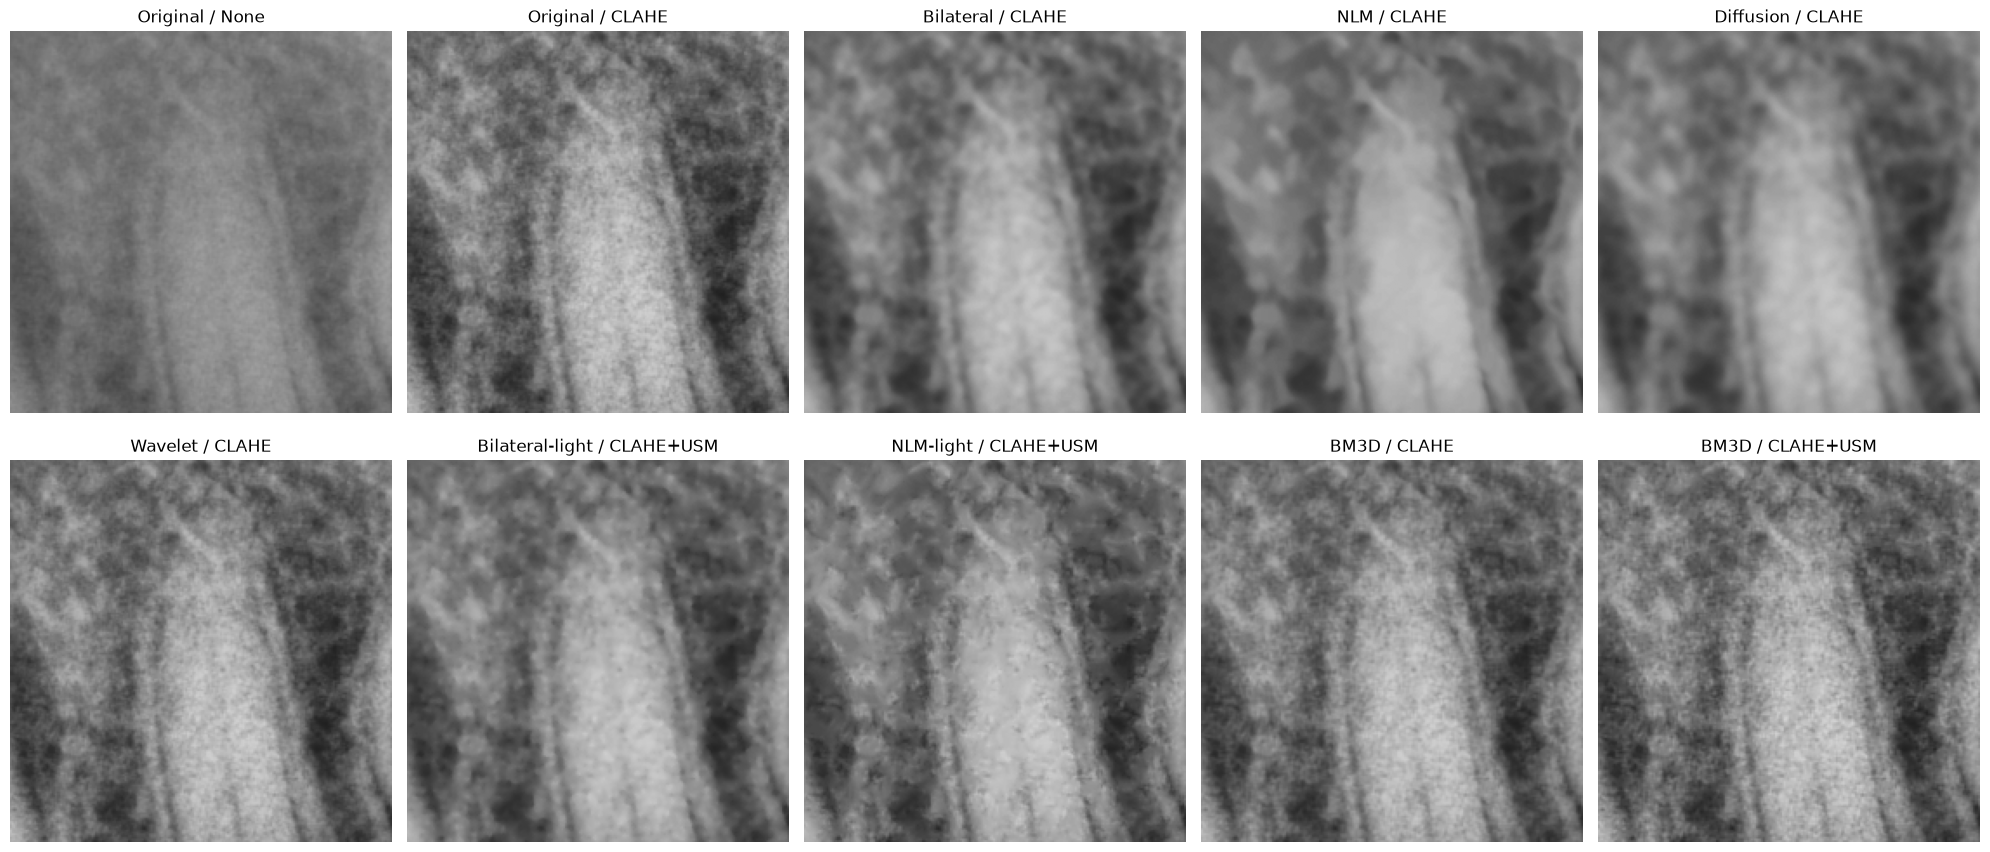

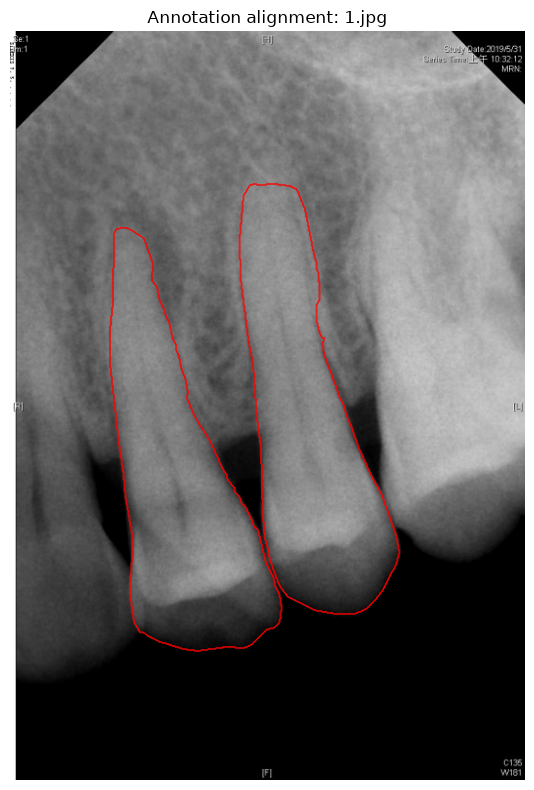

In [12]:
# 標註附近的局部比較：可修改 case_index 與 ROI。
cases = annotation_cases(PROJECT_ROOT / "data/seg_annotations/instances_default.json")
case_index = 0
comparison_image, comparison_boundary, _, _ = prepare_case(cases[case_index], evaluation_max_side)
ys, xs = np.where(comparison_boundary)
# 以標註最上方輪廓點為中心，保留同一個局部視野。
center = np.argmin(ys)
x0, y0 = max(0, int(xs[center]) - 100), max(0, int(ys[center]) - 60)
roi = (slice(y0, min(y0 + 220, comparison_image.shape[0])),
       slice(x0, min(x0 + 220, comparison_image.shape[1])))
comparison_candidates = [("Original", "None"), ("Original", "CLAHE"),
                         ("Bilateral", "CLAHE"), ("NLM", "CLAHE"),
                         ("Diffusion", "CLAHE"), ("Wavelet", "CLAHE"),
                         ("Bilateral-light", "CLAHE+USM"), ("NLM-light", "CLAHE+USM")]
if "BM3D" in DENOISERS:
    comparison_candidates += [("BM3D", "CLAHE"), ("BM3D", "CLAHE+USM")]
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for axis in axes.flat:
    axis.axis("off")
for axis, (method, mode) in zip(axes.flat, comparison_candidates):
    output = enhance_image(EVALUATION_DENOISERS[method](comparison_image), mode)
    axis.imshow(output[roi], cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"{method} / {mode}")
plt.tight_layout()
plt.savefig(report_dir / "boundary_comparison.png", dpi=150)
plt.show()

# 輪廓定位核對圖：標註用紅色顯示，確認幾何位置相符。
plt.figure(figsize=(8, 8))
plt.imshow(comparison_image, cmap="gray", vmin=0, vmax=255)
plt.contour(comparison_boundary.astype(float), levels=[0.5], colors="red", linewidths=0.5)
plt.title(f"Annotation alignment: {cases[case_index][0].name}")
plt.axis("off")
plt.tight_layout()
plt.savefig(report_dir / "annotation_alignment.png", dpi=120)
plt.show()


### 4. 本次評估結論與後續前處理入口

2026-10-07：101 張匹配牙齒標註影像，11 種設定 × 3 種增強，共 3333 筆結果；另 3 張原尺寸複查。

**起始建議：低強度 NLM（h=2）→ CLAHE → 輕度閾值式 unsharp mask。** 這是速度、顆粒抑制與弱邊緣保留的折衷；不是已證明的最佳方法。

| 方法（均 CLAHE+USM） | 輪廓覆蓋中位數 | 平坦區殘差中位數 | 秒/圖中位數 |
|---|---:|---:|---:|
| 不去雜訊 | 0.749 | 2.02 | 0.002 |
| Median 3×3 | 0.635 | 1.08 | 0.002 |
| NLM h=2 | 0.525 | 0.61 | 0.070 |
| BM3D 自動 sigma | 0.695 | 1.42 | 2.390 |

BM3D 組合在此設定下保留較多輪廓訊號，但抑制顆粒與執行時間的取捨不同；Median 可作快速且較保留細節的候選。強低通／強擴散會抹掉弱邊緣；Wavelet 自動 sigma 在本資料上效果接近未去雜訊，仍可另測手動 sigma。

原尺寸 3 張複查中，NLM-light+CLAHE+USM 的輪廓覆蓋中位數 0.703、平坦殘差 1.17；直接 CLAHE+USM 為 0.778、2.55。比較圖可見 NLM-light 減少顆粒，但仍有平滑細節的取捨。

縮圖、Canny 閾值、標註偏差與參數都影響結論；平坦殘差亦可能含骨紋理，輪廓覆蓋不能當作分割準確率。後續以分割 Dice／boundary F1 或 CEJ 定位誤差驗證。若有暈邊或過強顆粒，先設 `sharpen=False`。

完整結果：[assessment.md](../reports/preprocessing/assessment.md)、[summary.csv](../reports/preprocessing/summary.csv)、[原尺寸局部比較](../reports/preprocessing/native_boundary_comparison.png)。上表是本次執行的固定紀錄，改參數重跑後請以新產生的 CSV 為準。


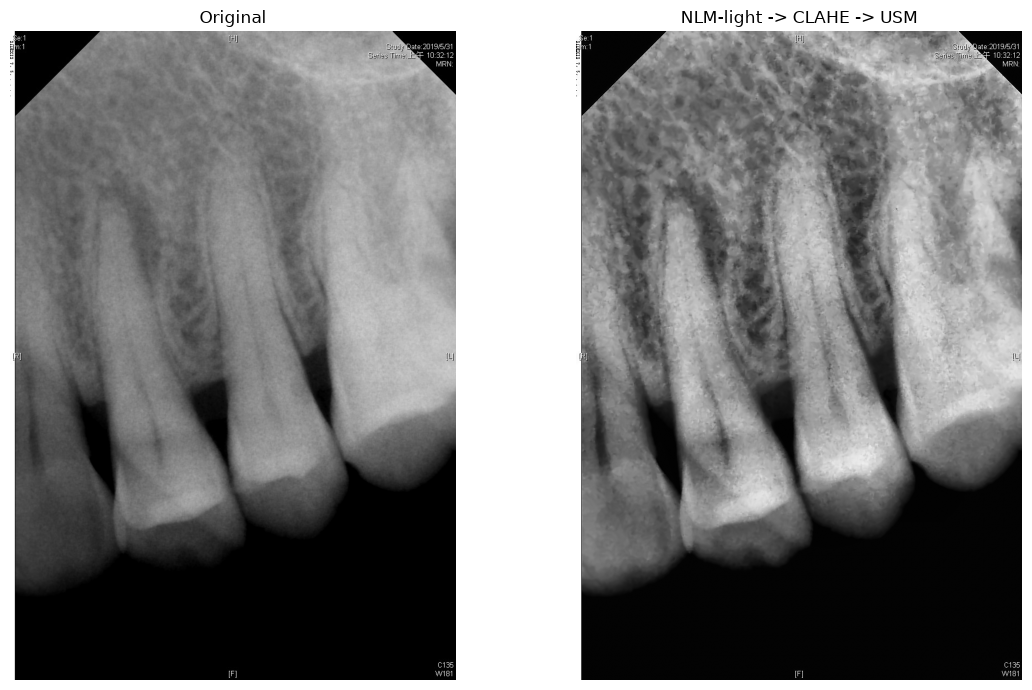

In [13]:
def preprocess_for_edges(image, method="NLM-light", sharpen=True):
    """供後續影像增強／分割使用；輸入與輸出皆為原尺寸 2D uint8。"""
    if image.ndim != 2 or image.dtype != np.uint8:
        raise ValueError("請先載入為 2D uint8 灰階影像。")
    if method not in EVALUATION_DENOISERS:
        raise ValueError(f"未知方法：{method}，可選 {list(EVALUATION_DENOISERS)}")
    denoised = EVALUATION_DENOISERS[method](image)
    return enhance_image(denoised, "CLAHE+USM" if sharpen else "CLAHE")


# 保留原尺寸，作為後續處理的輸入；不寫回原始檔案。
recommended_image = preprocess_for_edges(gray_image)
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for axis, image, title in zip(axes, [gray_image, recommended_image],
                            ["Original", "NLM-light -> CLAHE -> USM"]):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
